# Project 1: Data Collection and Initial Analysis of Stock Market Data

**Dataset:** Daily Historical Stock Prices (1970 - 2018)
**Author:** Jean Billa
**Program:** Diploma in Data Analysis and Artificial Intelligence, Willis College

## Objective

This notebook performs an end-to-end exploratory data analysis (EDA) of decades of daily
U.S. stock market data. The workflow covers: data collection, data cleaning, decade-based
segmentation, per-decade summary statistics, visualizations, and a comparative analysis
across decades, with sector information merged in from a companion reference table.

Two source files are used:

- `historical_stocks.csv` — one row per ticker, with exchange, company name, sector, and industry.
- `historical_stock_prices.csv` — one row per ticker per trading day, with open, high, low, close,
  adjusted close, and volume.


## 1. Data Collection

In [1]:
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.width', 140)

RNG = np.random.default_rng(42)  # fixed seed for reproducible sampling in plots

# This dataset has ~21 million daily price rows. To keep peak memory usage well within
# bounds on modest hardware, later cells deliberately `del` large intermediate objects
# and call gc.collect() once they are no longer needed, rather than keeping every
# intermediate DataFrame alive for the rest of the session.


In [2]:
# Load the reference table of tickers (small file, default dtypes are fine)
df_stocks = pd.read_csv('historical_stocks.csv')
print(df_stocks.shape)
df_stocks.head()


(6460, 5)


,ticker,exchange,name,sector,industry
0,PIH,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
1,PIHPP,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
2,TURN,NASDAQ,180 DEGREE CAPITAL CORP.,FINANCE,FINANCE/INVESTORS SERVICES
3,FLWS,NASDAQ,"1-800 FLOWERS.COM, INC.",CONSUMER SERVICES,OTHER SPECIALTY STORES
4,FCCY,NASDAQ,1ST CONSTITUTION BANCORP (NJ),FINANCE,SAVINGS INSTITUTIONS


In [3]:
df_stocks.info()


<class 'pandas.DataFrame'>
RangeIndex: 6460 entries, 0 to 6459
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   ticker    6460 non-null   str  
 1   exchange  6460 non-null   str  
 2   name      6460 non-null   str  
 3   sector    5020 non-null   str  
 4   industry  5020 non-null   str  
dtypes: str(5)
memory usage: 252.5 KB


In [4]:
# Load the daily prices file. This file has ~21 million rows, so we specify compact
# dtypes up front (float32 instead of float64, 'ticker' as a category) to keep the
# ~2 GB CSV comfortably inside memory once loaded, and parse the date column directly.
price_dtypes = {
    'ticker': 'category',
    'open': 'float32',
    'close': 'float32',
    'adj_close': 'float32',
    'low': 'float32',
    'high': 'float32',
    'volume': 'float32',
}

df_prices = pd.read_csv(
    'historical_stock_prices.csv',
    dtype=price_dtypes,
    parse_dates=['date'],
)
print(df_prices.shape)
df_prices.head()


(20973889, 8)


,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900.0,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800.0,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100.0,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400.0,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100.0,2013-05-14


In [5]:
df_prices.info()


<class 'pandas.DataFrame'>
RangeIndex: 20973889 entries, 0 to 20973888
Data columns (total 8 columns):
 #   Column     Dtype         
---  ------     -----         
 0   ticker     category      
 1   open       float32       
 2   close      float32       
 3   adj_close  float32       
 4   low        float32       
 5   high       float32       
 6   volume     float32       
 7   date       datetime64[us]
dtypes: category(1), datetime64[us](1), float32(6)
memory usage: 680.2 MB


## 2. Data Cleaning

We check both tables for missing values, duplicate records, and logically invalid rows,
then convert/verify the date column and set it as the DataFrame index.


In [6]:
# --- Missing values -------------------------------------------------------
print("Missing values in df_stocks:")
print(df_stocks.isna().sum())
print()
print("Missing values in df_prices:")
print(df_prices.isna().sum())


Missing values in df_stocks:
ticker         0
exchange       0
name           0
sector      1440
industry    1440
dtype: int64

Missing values in df_prices:
ticker       0
open         0
close        0
adj_close    0
low          0
high         0
volume       0
date         0
dtype: int64


In [7]:
# sector/industry are missing for some tickers (typically newer or thinly-covered
# listings). Rather than dropping these tickers -- which would silently remove real
# trading history from the analysis -- we label them explicitly as 'UNKNOWN' so they
# stay visible as their own category in later group-by operations.
df_stocks['sector'] = df_stocks['sector'].fillna('UNKNOWN')
df_stocks['industry'] = df_stocks['industry'].fillna('UNKNOWN')

print(f"Tickers with unknown sector: {(df_stocks['sector'] == 'UNKNOWN').sum()} / {len(df_stocks)}")

# df_prices itself has no missing values in any column, so no imputation is needed there.


Tickers with unknown sector: 1440 / 6460


In [8]:
# --- Duplicate records -----------------------------------------------------
# A ticker should not report two different price rows for the same trading day, so
# (ticker, date) is the natural key we check for duplication.
n_dupe_keys = df_prices.duplicated(subset=['ticker', 'date']).sum()
print(f"Duplicate (ticker, date) rows: {n_dupe_keys}")

n_dupe_tickers = df_stocks['ticker'].duplicated().sum()
print(f"Duplicate tickers in df_stocks: {n_dupe_tickers}")

df_prices = df_prices.drop_duplicates(subset=['ticker', 'date'])
df_stocks = df_stocks.drop_duplicates(subset=['ticker'])


Duplicate (ticker, date) rows: 0
Duplicate tickers in df_stocks: 0


In [9]:
# --- Logical validity checks ------------------------------------------------
# Beyond missing/duplicate values, we check for rows that are internally inconsistent,
# e.g. a reported High below the reported Low, or non-positive prices/volume.
n_bad_range = (df_prices['high'] < df_prices['low']).sum()
n_nonpos_price = (df_prices[['open', 'high', 'low', 'close']] <= 0).any(axis=1).sum()
n_neg_volume = (df_prices['volume'] < 0).sum()

print(f"Rows where High < Low: {n_bad_range}")
print(f"Rows with a non-positive price: {n_nonpos_price}")
print(f"Rows with negative volume: {n_neg_volume}")

before = len(df_prices)
df_prices = df_prices.loc[df_prices['high'] >= df_prices['low']]
print(f"Removed {before - len(df_prices)} rows with High < Low as data-entry errors.")


Rows where High < Low: 48
Rows with a non-positive price: 0
Rows with negative volume: 0


Removed 48 rows with High < Low as data-entry errors.


In [10]:
# --- Date handling -----------------------------------------------------------
# 'date' was already parsed to datetime64 on load. We set it as the DataFrame index
# (kept also as a regular column, since we need it for group-by operations below)
# so the data behaves as a proper time series.
df_prices = df_prices.set_index('date', drop=False)
df_prices = df_prices.sort_index()
print(df_prices.index.min(), "to", df_prices.index.max())
df_prices.head()


1970-01-02 00:00:00 to 2018-08-24 00:00:00


,ticker,open,close,adj_close,low,high,volume,date
date,,,,,,,,
1970-01-02,AEP,30.125000,30.625000,0.983416,30.125000,31.000000,10300.0,1970-01-02
1970-01-02,IP,9.153107,9.430473,1.183667,9.122288,9.461292,71700.0,1970-01-02
1970-01-02,CVX,3.195312,3.265625,0.072620,3.195312,3.265625,526400.0,1970-01-02
1970-01-02,PG,1.710938,1.718750,0.020346,1.708984,1.722656,832000.0,1970-01-02
1970-01-02,XOM,1.929688,1.937500,0.025623,1.925781,1.937500,1174400.0,1970-01-02


## 3. Data Segmentation by Decade

We merge sector/industry information from `df_stocks` into the price data, add a `decade`
column, and split the result into one DataFrame per decade.


In [11]:
# Merge sector/industry info onto every price row using the ticker as the join key.
df = df_prices.merge(df_stocks[['ticker', 'sector', 'industry']], on='ticker', how='left')
# Cast to 'category': there are only ~13 distinct sectors, so storing them as a Python
# string object on all ~21 million rows would waste a large amount of memory.
df['sector'] = df['sector'].fillna('UNKNOWN').astype('category')
df['industry'] = df['industry'].fillna('UNKNOWN').astype('category')
df.index = df_prices.index  # merge resets the index; restore the date index

# df_prices has now been fully absorbed into df; free it before continuing so we are
# never holding two ~2 GB copies of the price data in memory at the same time.
del df_prices
gc.collect()

print(df.shape)
df.head()


(20973841, 10)


,ticker,open,close,adj_close,low,high,volume,date,sector,industry
date,,,,,,,,,,
1970-01-02,AEP,30.125000,30.625000,0.983416,30.125000,31.000000,10300.0,1970-01-02,PUBLIC UTILITIES,ELECTRIC UTILITIES: CENTRAL
1970-01-02,IP,9.153107,9.430473,1.183667,9.122288,9.461292,71700.0,1970-01-02,BASIC INDUSTRIES,PAPER
1970-01-02,CVX,3.195312,3.265625,0.072620,3.195312,3.265625,526400.0,1970-01-02,ENERGY,INTEGRATED OIL COMPANIES
1970-01-02,PG,1.710938,1.718750,0.020346,1.708984,1.722656,832000.0,1970-01-02,BASIC INDUSTRIES,PACKAGE GOODS/COSMETICS
1970-01-02,XOM,1.929688,1.937500,0.025623,1.925781,1.937500,1174400.0,1970-01-02,ENERGY,INTEGRATED OIL COMPANIES


In [12]:
# Create the decade column, e.g. 1987 -> 1980, 2016 -> 2010.
df['decade'] = (df['date'].dt.year // 10 * 10).astype('int16')

decade_counts = df['decade'].value_counts().sort_index()
print(decade_counts)


decade
1970     164499
1980    1470571
1990    3427832
2000    6572030
2010    9338909
Name: count, dtype: int64


## 4. Exploratory Data Analysis by Decade

### 4.1 Summary statistics

For each decade we compute the mean, median, and standard deviation of Open, High, Low,
Close, and Volume. This is computed once on the full merged DataFrame (before segmenting
into separate per-decade DataFrames below), which is more memory-efficient than repeating
the aggregation five times over five separate copies.


In [13]:
summary_stats = df.groupby('decade', observed=True)[
    ['open', 'high', 'low', 'close', 'volume']
].agg(['mean', 'median', 'std']).round(2)

summary_stats


open                            high                                 low                               close         \
              mean median          std        mean     median          std        mean     median          std        mean median   
decade                                                                                                                              
1970     12.490000   2.79    46.980000   12.640000   2.840000    47.480000   12.370000   2.770000    46.509998   12.490000   2.79   
1980     16.809999   5.00   573.049988   17.100000   5.080000   582.809998   16.559999   4.960000   562.260010   16.820000   5.00   
1990     45.290001  10.58  1391.109985   46.869999  10.750000  1464.630005   43.810001  10.440000  1329.329956   45.299999  10.59   
2000    122.290001  16.58  4485.640137  125.639999  16.870001  4703.970215  119.160004  16.299999  4318.830078  122.430000  16.58   
2010     65.260002  20.01  1820.180054   66.720001  20.280001  1941.569946   63.919998  19.750000  1763.140015   65.279999  20.01   

                          volume                         
                std         mean    median          std  
decade                                                   
1970      46.990002   724893.625  187200.0   1377365.79  
1980     575.030029   837523.375   64600.0   4510088.44  
1990    1391.579956   863527.250   62200.0   5834011.90  
2000    4509.790039  1383567.250  133400.0   9230158.64  
2010    1850.130005  1320508.500  165400.0  17707911.81

In [14]:
summary_stats.to_csv('outputs/decade_summary_statistics.csv')
print("Saved outputs/decade_summary_statistics.csv")


Saved outputs/decade_summary_statistics.csv


### 4.2 Sector coverage over time (computed before segmentation)

We also compute the sector composition by decade here, on the full `df`, before splitting
into per-decade DataFrames -- again to avoid holding both the full dataset and five
decade-level copies in memory at once.


In [15]:
sector_share = (
    df.groupby(['decade', 'sector'], observed=True)['ticker']
    .nunique()
    .unstack(fill_value=0)
)
sector_share_pct = sector_share.div(sector_share.sum(axis=1), axis=0) * 100
sector_share_pct.round(1)


sector,BASIC INDUSTRIES,CAPITAL GOODS,CONSUMER DURABLES,CONSUMER NON-DURABLES,CONSUMER SERVICES,ENERGY,FINANCE,HEALTH CARE,MISCELLANEOUS,PUBLIC UTILITIES,TECHNOLOGY,TRANSPORTATION,UNKNOWN
decade,,,,,,,,,,,,,
1970,6.5,16.1,3.2,10.8,12.9,9.7,6.5,8.6,1.1,10.8,10.8,1.1,2.2
1980,7.7,12.8,4.7,7.1,11.9,5.9,15.3,7.0,1.7,7.4,9.5,2.0,7.1
1990,6.0,10.2,3.8,5.9,14.2,5.1,17.1,8.8,2.3,5.4,11.5,1.9,7.9
2000,5.6,7.8,3.0,4.6,13.6,4.8,16.5,9.9,2.7,5.0,10.7,2.2,13.5
2010,4.6,6.1,2.4,3.8,13.4,4.9,16.1,13.1,2.4,4.6,10.5,2.0,16.1


In [16]:
# Segment into one DataFrame per decade for decade-level analysis. `df` itself is no
# longer needed once this split is done, so we free it immediately afterward.
decades = sorted(df['decade'].unique())
decade_dfs = {d: df[df['decade'] == d] for d in decades}

del df
gc.collect()

for d in decades:
    n_rows = len(decade_dfs[d])
    n_tickers = decade_dfs[d]['ticker'].nunique()
    print(f"{d}s: {n_rows:,} rows, {n_tickers:,} unique tickers")


1970s: 164,499 rows, 93 unique tickers
1980s: 1,470,571 rows, 901 unique tickers
1990s: 3,427,832 rows, 2,117 unique tickers


2000s: 6,572,030 rows, 3,429 unique tickers


2010s: 9,338,909 rows, 5,685 unique tickers


### 4.2 Time series: average monthly Close price per decade

Because far more tickers are listed in later decades (93 in the 1970s vs. 5,685 by the
2010s), and individual share prices span several orders of magnitude, the average monthly
Close is plotted on a **log scale** within each decade panel so trends remain visible in
every period.


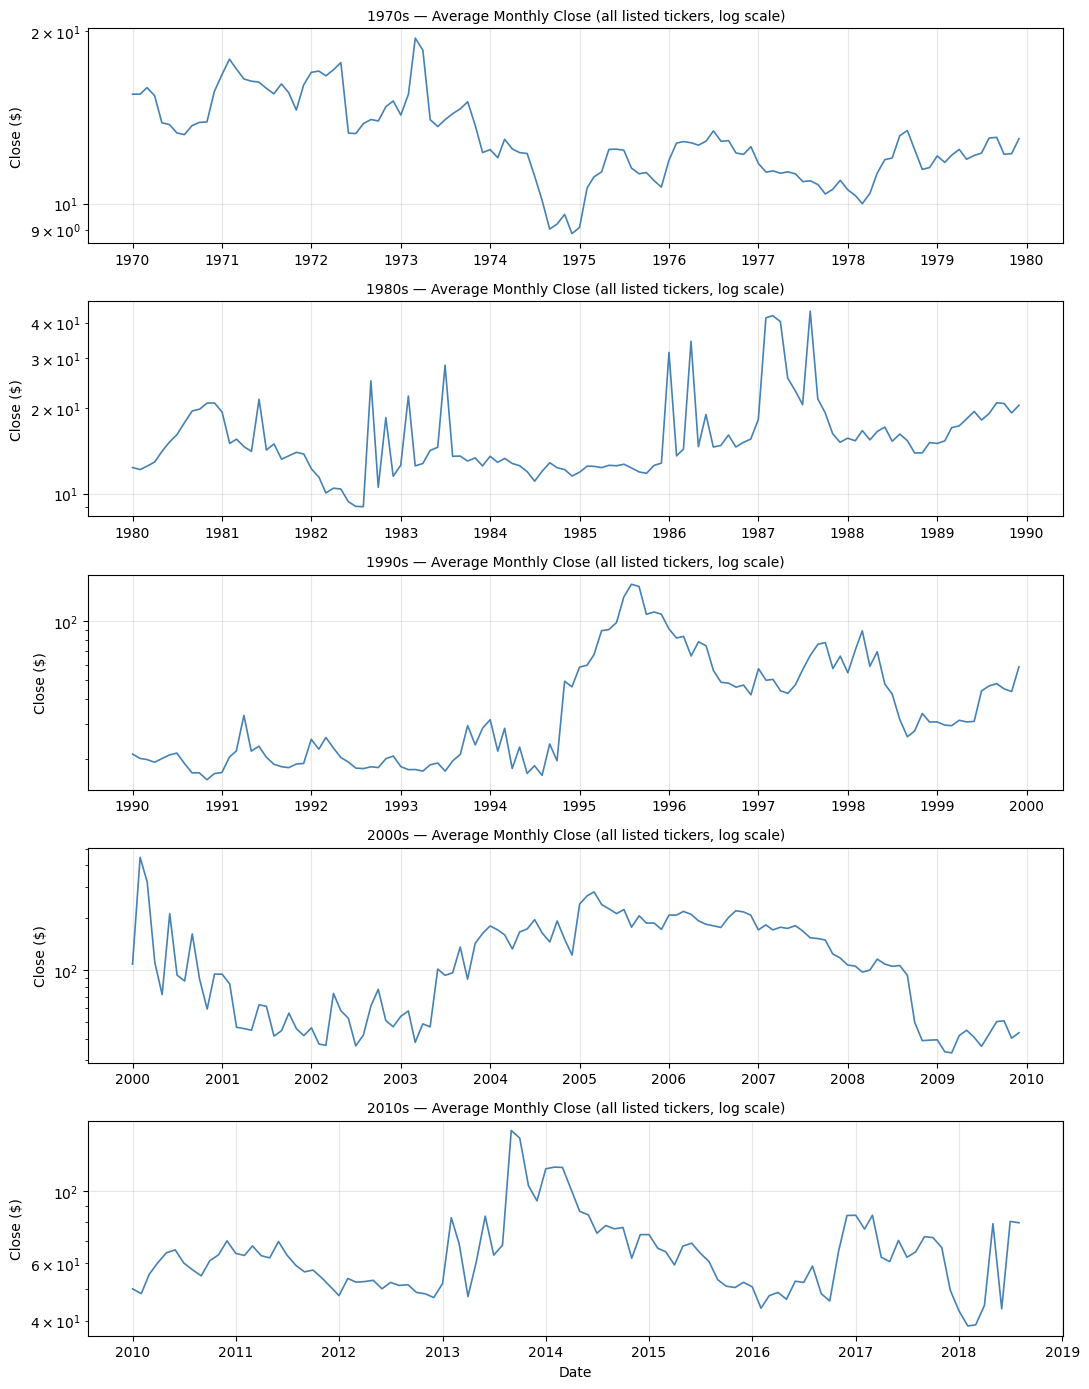

In [17]:
fig, axes = plt.subplots(len(decades), 1, figsize=(11, 14))

for ax, d in zip(axes, decades):
    sub = decade_dfs[d]
    monthly_close = sub.groupby(sub['date'].dt.to_period('M'), observed=True)['close'].mean()
    ax.plot(monthly_close.index.to_timestamp(), monthly_close.values,
            color='steelblue', linewidth=1.2)
    ax.set_yscale('log')
    ax.set_title(f'{d}s — Average Monthly Close (all listed tickers, log scale)', fontsize=10)
    ax.set_ylabel('Close ($)')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('figures/01_monthly_close_by_decade.png', dpi=120)
plt.show()


### 4.3 Volume distribution per decade

Trading volume is heavily right-skewed in every decade, so a log10 transform is applied
before plotting the histogram.


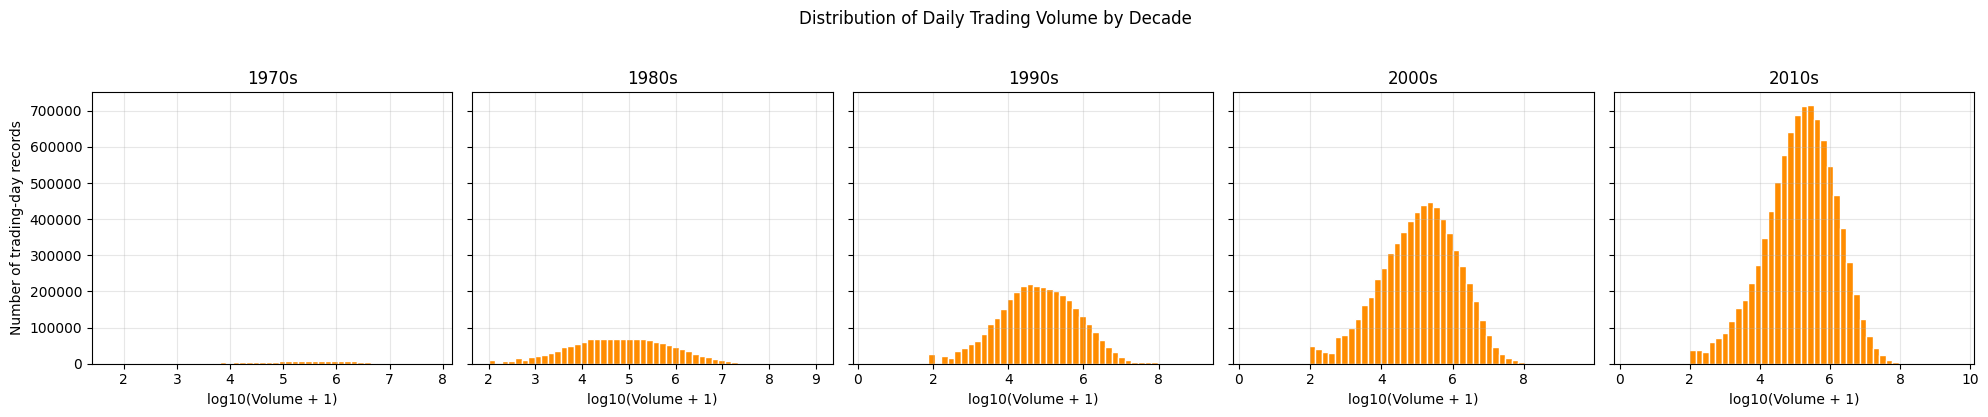

In [18]:
fig, axes = plt.subplots(1, len(decades), figsize=(20, 4), sharey=True)

for ax, d in zip(axes, decades):
    sub = decade_dfs[d]
    ax.hist(np.log10(sub['volume'].values + 1), bins=50, color='darkorange', edgecolor='white')
    ax.set_title(f'{d}s')
    ax.set_xlabel('log10(Volume + 1)')

axes[0].set_ylabel('Number of trading-day records')
plt.suptitle('Distribution of Daily Trading Volume by Decade', y=1.03)
plt.tight_layout()
plt.savefig('figures/02_volume_histograms_by_decade.png', dpi=120, bbox_inches='tight')
plt.show()


### 4.4 High / Low price range per decade

Boxplots compare the spread and outliers of daily High and Low prices across decades.
Each decade contains millions of rows, so for legibility and rendering performance we draw
the boxplot from a fixed random sample of up to 50,000 rows per decade (same seed as the
rest of the notebook) rather than every single record; the summary statistics in Section
4.1 already reflect the **full**, unsampled dataset. Extreme outliers are hidden
(`showfliers=False`) since a handful of very high-priced stocks (e.g. Berkshire Hathaway)
would otherwise compress the rest of the box down to an unreadable sliver.


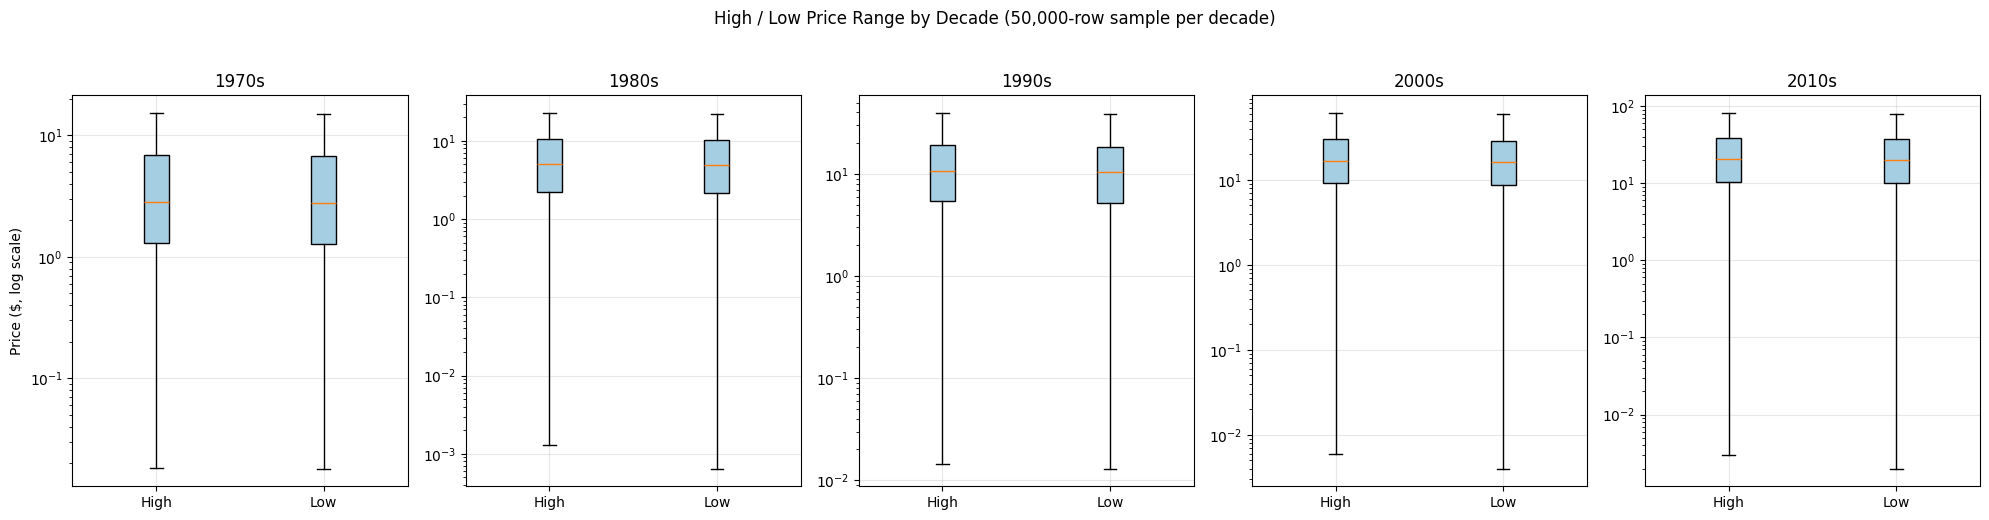

In [19]:
fig, axes = plt.subplots(1, len(decades), figsize=(20, 5), sharey=False)

for ax, d in zip(axes, decades):
    sub = decade_dfs[d]
    n = len(sub)
    sample_n = min(50_000, n)
    sample_idx = RNG.choice(n, size=sample_n, replace=False)
    sample = sub.iloc[sample_idx]
    ax.boxplot(
        [sample['high'].values, sample['low'].values],
        tick_labels=['High', 'Low'],
        showfliers=False,
        patch_artist=True,
        boxprops=dict(facecolor='#a6cee3'),
    )
    ax.set_title(f'{d}s')
    ax.set_yscale('log')

axes[0].set_ylabel('Price ($, log scale)')
plt.suptitle('High / Low Price Range by Decade (50,000-row sample per decade)', y=1.03)
plt.tight_layout()
plt.savefig('figures/03_high_low_boxplots_by_decade.png', dpi=120, bbox_inches='tight')
plt.show()


### 4.5 Sector coverage over time (visualized)

Using the `sector_share_pct` table computed in Section 4.2, before the DataFrame was
segmented by decade.


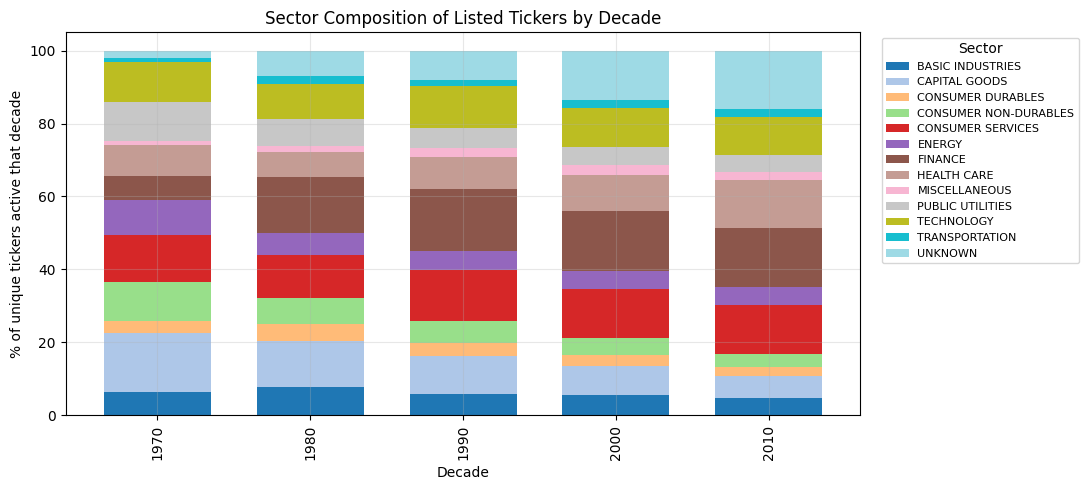

In [20]:
fig, ax = plt.subplots(figsize=(11, 5))
sector_share_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.7)
ax.set_ylabel('% of unique tickers active that decade')
ax.set_xlabel('Decade')
ax.set_title('Sector Composition of Listed Tickers by Decade')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Sector')
plt.tight_layout()
plt.savefig('figures/04_sector_composition_by_decade.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. Comparative Analysis Across Decades

**Coverage.** The dataset's breadth grows enormously over time: only 93 tickers have any
trading history in the 1970s, versus 5,685 by the 2010s. Any comparison of early vs. late
decades is therefore also a comparison of a small, survivorship-biased set of long-lived
companies against a much broader and more representative cross-section of the market —
this is an important caveat for every trend described below.

**Price levels.** Median Close price rises steadily across decades: \$2.79 (1970s) →
\$5.00 (1980s) → \$10.59 (1990s) → \$16.58 (2000s) → \$20.01 (2010s). This reflects
a combination of genuine long-run market growth, inflation, and the fact that newly listed
companies added in later decades increasingly set their own price bases. Mean price and its
standard deviation are far larger and far more volatile than the median in every decade
(e.g. mean Open of \$122 vs. median Open of \$16.58 in the 2000s), which shows the
distribution is heavily right-skewed by a small number of very high-priced stocks — the
same effect visible in the compressed boxplots in Section 4.4.

**Trading volume.** Mean daily volume rises from roughly 725K shares (1970s) to 1.38M
shares (2000s) before dipping slightly to 1.32M in the 2010s. Median volume, however, is
non-monotonic: it drops from 187K (1970s) to just 62–65K in the 1980s–1990s, then climbs
back to 165K by the 2010s. The 1970s subset is a small, survivor-biased group of
already-established, heavily-traded names, so its high starting median is not surprising;
as the exchange listed thousands of smaller, less liquid companies through the 1980s–90s,
the median trading day's volume fell even as aggregate market volume grew, before recovering
as electronic trading expanded participation from the 2000s onward.

**Volatility proxy.** Using the intraday range as a share of Close price
((High − Low) / Close), average daily volatility rises from 2.62% (1970s) to a peak of
3.90% in the 2000s — consistent with the dot-com crash (2000–2002) and the 2008 financial
crisis both falling inside that decade — before easing to 3.15% in the 2010s.

**Sector composition.** Finance, Consumer Services, Technology, and Health Care are the
four largest sectors by row count across the full dataset. The share of tickers with no
recorded sector ('UNKNOWN') grows substantially in the 2000s and 2010s, which likely
reflects newer listings (including ETFs and smaller companies) that the reference table
has not fully classified, rather than a real shift in the market's sector mix.


## 6. Hypotheses for Further Analysis

Based on this initial EDA, the following hypotheses are proposed for deeper investigation
in later projects:

1. **Survivorship bias drives part of the apparent price growth.** Because only companies
   that kept reporting data are included in early decades, comparing raw price levels
   across decades likely overstates genuine market appreciation. A cap-weighted or
   return-based index (rather than a simple average of Close prices) would better isolate
   real market trends from composition effects.
2. **Volatility spikes coincide with known crisis periods.** The elevated 2000s
   intraday-range volatility is consistent with the dot-com crash and 2008 financial
   crisis; a year-by-year (rather than decade-by-decade) breakdown should show sharp,
   short-lived volatility spikes around 2001 and 2008 rather than a uniformly higher level
   throughout the decade.
3. **Sector mix affects volume and volatility differently.** Given the very different
   average volumes by sector, later analysis should test whether sector is a meaningful
   predictor of volume and price volatility, independent of overall market conditions.
4. **The declining then rising median volume reflects market microstructure changes,**
   e.g. the shift from floor-based to electronic trading in the late 1990s/2000s, and the
   growth in the number of thinly-traded small-cap listings from the 1980s onward diluting
   the median even as aggregate volume rose.

## 7. Methodology Notes

- Source files: `historical_stocks.csv` (6,460 tickers) and `historical_stock_prices.csv`
  (~21.0 million daily price records, 1970-01-02 to 2018-08-24).
- Compact dtypes (`float32`, `category`) were used on load to keep the ~2 GB price file
  within a manageable memory footprint; this has no material effect on the summary
  statistics reported (float32 retains ~7 significant digits of precision).
- Missing `sector`/`industry` values were labeled `'UNKNOWN'` rather than dropped, to avoid
  silently discarding real trading history for unclassified tickers.
- 48 rows with `High < Low` were removed as data-entry errors; no duplicate
  `(ticker, date)` records or missing price values were found.
- Boxplots in Section 4.4 are drawn from a fixed 50,000-row-per-decade random sample
  (seed 42) purely for rendering legibility/performance; all summary statistics in Section
  4.1 use the complete, unsampled dataset.
